# LFP Coherence Analysis – All Subjects (d0 vs d7)
This notebook loads aligned LFP collections for all subjects and visualizes coherence 
between brain regions (mPFC, MD, NAc, BLA, vHPC) across time and frequency.


In [9]:
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=TqdmWarning)


# Check current sys.path
print("Current sys.path:")
for p in sys.path:
    print("  ", p)

# === Add the ephys_analysis path ===
# This points to Thomas's shared repo where LFPCollection and coherence functions live
ephys_repo_path = "/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis"

if ephys_repo_path not in sys.path:
    sys.path.append(ephys_repo_path)
    print(f"Added to sys.path: {ephys_repo_path}")
else:
    print(f"Path already exists in sys.path: {ephys_repo_path}")

# === Import LFPCollection from the LFP module ===
from LFP.lfp_collection import LFPCollection
print("Successfully imported LFPCollection.")


Current sys.path:
   /blue/npadillacoreano/sequioasmith/rehouse_code/diff_fam_social_memory_ephys/sequioa-notebooks
   /blue/npadillacoreano/sequioasmith/.conda/envs/ephys_env/lib/python310.zip
   /blue/npadillacoreano/sequioasmith/.conda/envs/ephys_env/lib/python3.10
   /blue/npadillacoreano/sequioasmith/.conda/envs/ephys_env/lib/python3.10/lib-dynload
   
   /blue/npadillacoreano/sequioasmith/.conda/envs/ephys_env/lib/python3.10/site-packages
   /blue/npadillacoreano/sequioasmith/ephys_analysis
   /blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis
   /blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis
   /blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis
Path already exists in sys.path: /blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis
Successfully imported LFPCollection.


In [3]:
# Correct absolute path
json_path = "/blue/npadillacoreano/sequioasmith/rehouse_code/lfp_collections/aligned_lfpcollection_all_subj_d0_d7.json"

# Load the collection
lfp_collection = LFPCollection.load_collection(json_path)

# Confirm successful load
print(f"Loaded {len(lfp_collection.recordings)} recordings")
print("Brain regions:", list(lfp_collection.brain_region_dict.keys()))


Loaded 12 recordings
Brain regions: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']


In [4]:
lfp_collection.preprocess()

  0%|          | 0/12 [00:00<?, ?it/s]

processing 41_rehouse_d7_merged.rec


  8%|▊         | 1/12 [00:00<00:08,  1.29it/s]

RMS Traces calculated
processing 23_rehouse_d7_merged.rec


 17%|█▋        | 2/12 [00:01<00:06,  1.45it/s]

...

RMS Traces calculated
processing 31_rehouse_d0_merged.rec


 92%|█████████▏| 11/12 [00:06<00:00,  1.62it/s]

RMS Traces calculated
processing 32_rehouse_d0_merged.rec


100%|██████████| 12/12 [00:07<00:00,  1.59it/s]

RMS Traces calculated


In [5]:
lfp_collection.calculate_coherence()

  8%|▊         | 1/12 [00:05<01:05,  5.98s/it]

Coherence calcualatd


 17%|█▋        | 2/12 [00:11<00:58,  5.83s/it]

Coherence calcualatd


 25%|██▌       | 3/12 [00:17<00:52,  5.79s/it]

...

Coherence calcualatd


 92%|█████████▏| 11/12 [01:05<00:05,  5.99s/it]

Coherence calcualatd


100%|██████████| 12/12 [01:11<00:00,  5.93s/it]

Coherence calcualatd


In [6]:
for rec in lfp_collection.recordings:
    print(f"Recording: {rec.name} (Subject: {rec.subject}) — Regions: {list(rec.brain_region_dict.keys())}")


Recording: 41_rehouse_d7_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 23_rehouse_d7_merged.rec (Subject: 23) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 31_rehouse_d7_merged.rec (Subject: 31) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d7_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 23_rehouse_d0_merged.rec (Subject: 23) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 22_rehouse_d7_merged.rec (Subject: 22) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 22_rehouse_d0_merged.rec (Subject: 22) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 32_rehouse_d7_merged.rec (Subject: 32) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d0_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d0_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 31_rehous

### Shape of Coherence:
coh.shape → (T, F, R, R):

T: time bins (based on window + step)

F: frequencies (based on multitaper settings)

R: brain regions (length of brain_region_dict)


This shape tells us what dimensions our coherence data has:

| Dimension | Meaning | Example in our data |
|------------|----------|--------------------|
| **T = 3600** | Number of time bins | The 30-minute recording was divided into small overlapping windows. Each window is 1 second long, and the analysis moves forward by 0.5 seconds each step. This means every second of the 30-minute recording is covered twice — once starting at the current time, and again starting 0.5 seconds later — giving **3600 small time segments**. |
| **F = 500** | Number of frequency points | The analysis looks at 500 frequency values between about 0.5 Hz and 300 Hz. This gives a smooth curve for coherence across the frequency spectrum. |
| **R × R = 5 × 5** | Brain region pairs | Coherence is measured between all pairs of regions. Since we have 5 regions (mPFC, MD, NAc, BLA, vHPC), the output is a 5×5 matrix showing coherence between every pair. The diagonal shows self-coherence (always 1.0). |

**In short:**  
Each 30-minute recording is broken into 3600 overlapping 1-second chunks, and for each chunk, the coherence between every pair of 5 regions is computed across 500 frequencies.  

So the data at: coh[t, f, i, j]
represents **how synchronized** region *i* and region *j* were at time *t* and frequency *f*.


In [7]:
d0_44_coh = lfp_collection.recordings[0].coherence
print(d0_44_coh.shape)

(3600, 500, 5, 5)


In [8]:
print(list(lfp_collection.brain_region_dict.keys()))


['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']


In [11]:
epoch_bins = {
    "baseline": slice(0, 1200),    # 0–10 min
    "first":    slice(1200, 2400), # 10–20 min
    "second":   slice(2400, 3600)  # 20–30 min
}

In [12]:
condition_order = {
    "22": "OM",
    "23": "OM",
    "31": "MO",
    "32": "MO",
    "41": "MO",
    "44": "OM",
}

In [26]:
def get_epoch_labels(subject):
    order = condition_order.get(subject)
    if order == "MO":
        return {"social": "first", "object": "second"}
    elif order == "OM":
        return {"social": "second", "object": "first"}
    else:
        raise ValueError(f"Unknown order for subject {subject}")


In [36]:
import numpy as np
import matplotlib.pyplot as plt

def compute_epoch_coherence(recording, subject, region_pair=("mPFC", "MD")):
    """Compute baseline, social, and object coherence for a given subject."""
    coh = recording.coherence
    regions = list(recording.brain_region_dict.keys())
    i, j = regions.index(region_pair[0]), regions.index(region_pair[1])

    # infer frequencies if not stored
    num_freqs = coh.shape[1]
    freqs = np.linspace(0.5, 300, num_freqs)

    # assign epochs based on counterbalance order (MO or OM)
    labels = get_epoch_labels(subject)

    baseline = np.nanmean(coh[epoch_bins["baseline"], :, i, j], axis=0)
    social   = np.nanmean(coh[epoch_bins[labels["social"]], :, i, j], axis=0)
    object_  = np.nanmean(coh[epoch_bins[labels["object"]], :, i, j], axis=0)
    return freqs, baseline, social, object_


# --- Run across subjects, split by day ---
baseline_d0, social_d0, object_d0 = [], [], []
baseline_d7, social_d7, object_d7 = [], [], []

for rec in lfp_collection.recordings:
    subj = rec.subject
    name = rec.name.lower()

    if subj not in condition_order:
        continue

    freqs, baseline, social, object_ = compute_epoch_coherence(rec, subj)

    # Separate recordings by day
    if "d0" in name:
        baseline_d0.append(baseline)
        social_d0.append(social)
        object_d0.append(object_)
    elif "d7" in name:
        baseline_d7.append(baseline)
        social_d7.append(social)
        object_d7.append(object_)

# --- Average across subjects per day ---
mean_baseline_d0 = np.nanmean(baseline_d0, axis=0)
mean_social_d0   = np.nanmean(social_d0, axis=0)
mean_object_d0   = np.nanmean(object_d0, axis=0)

mean_baseline_d7 = np.nanmean(baseline_d7, axis=0)
mean_social_d7   = np.nanmean(social_d7, axis=0)
mean_object_d7   = np.nanmean(object_d7, axis=0)

# --- Compute SEM per day ---
sem_social_d0 = np.nanstd(social_d0, axis=0) / np.sqrt(len(social_d0))
sem_object_d0 = np.nanstd(object_d0, axis=0) / np.sqrt(len(object_d0))
sem_social_d7 = np.nanstd(social_d7, axis=0) / np.sqrt(len(social_d7))
sem_object_d7 = np.nanstd(object_d7, axis=0) / np.sqrt(len(object_d7))


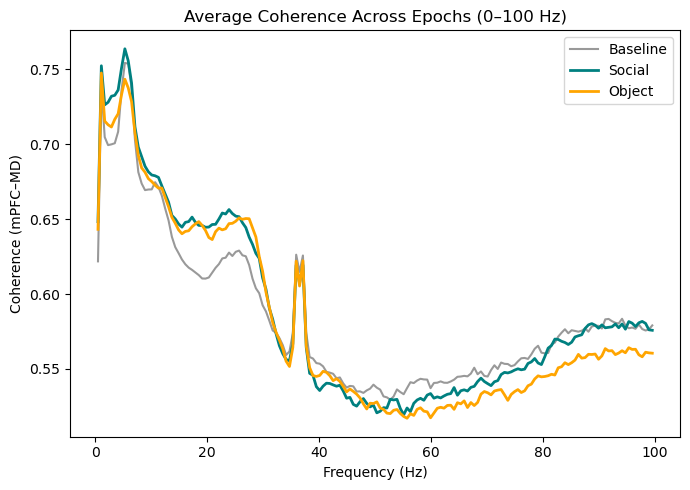

In [37]:
valid = freqs <= 100
plt.figure(figsize=(7,5))
plt.plot(freqs[valid], mean_baseline[valid], label="Baseline", color="gray", alpha=0.8)
plt.plot(freqs[valid], mean_social[valid],   label="Social", color="teal", lw=2)
plt.plot(freqs[valid], mean_object[valid],   label="Object", color="orange", lw=2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence (mPFC–MD)")
plt.title("Average Coherence Across Epochs (0–100 Hz)")
plt.legend()
plt.tight_layout()
plt.show()



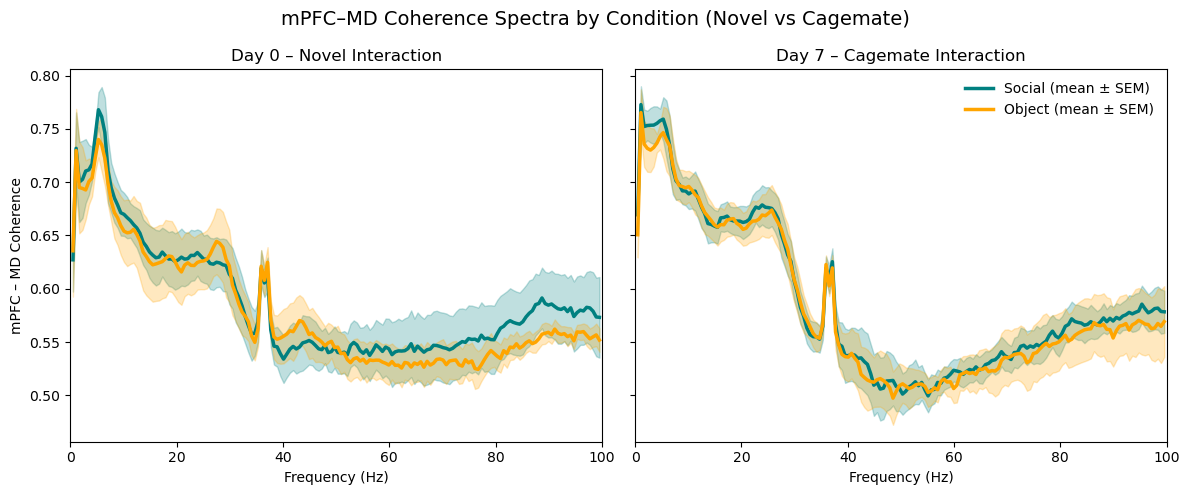

In [40]:
# --- Select frequency range (e.g., 0–100 Hz) ---
valid = freqs <= 100

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------- Novel (Day 0) ----------
axs[0].plot(freqs[valid], mean_social_d0[valid], color="teal", lw=2.5, label="Social (mean ± SEM)")
axs[0].fill_between(freqs[valid],
                    mean_social_d0[valid] - sem_social_d0[valid],
                    mean_social_d0[valid] + sem_social_d0[valid],
                    color="teal", alpha=0.25)

axs[0].plot(freqs[valid], mean_object_d0[valid], color="orange", lw=2.5, label="Object (mean ± SEM)")
axs[0].fill_between(freqs[valid],
                    mean_object_d0[valid] - sem_object_d0[valid],
                    mean_object_d0[valid] + sem_object_d0[valid],
                    color="orange", alpha=0.25)

axs[0].set_title("Day 0 – Novel Interaction")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_xlim(0, 100)
axs[0].set_ylabel("mPFC – MD Coherence")

# ---------- Cagemate (Day 7) ----------
axs[1].plot(freqs[valid], mean_social_d7[valid], color="teal", lw=2.5, label="Social (mean ± SEM)")
axs[1].fill_between(freqs[valid],
                    mean_social_d7[valid] - sem_social_d7[valid],
                    mean_social_d7[valid] + sem_social_d7[valid],
                    color="teal", alpha=0.25)

axs[1].plot(freqs[valid], mean_object_d7[valid], color="orange", lw=2.5, label="Object (mean ± SEM)")
axs[1].fill_between(freqs[valid],
                    mean_object_d7[valid] - sem_object_d7[valid],
                    mean_object_d7[valid] + sem_object_d7[valid],
                    color="orange", alpha=0.25)

axs[1].set_title("Day 7 – Cagemate Interaction")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_xlim(0, 100)
axs[1].legend(frameon=False, loc="upper right")

fig.suptitle("mPFC–MD Coherence Spectra by Condition (Novel vs Cagemate)", fontsize=14)
plt.tight_layout()
plt.show()



In [41]:
diff_d0 = np.array(social_d0) - np.array(object_d0)
diff_d7 = np.array(social_d7) - np.array(object_d7)

mean_diff_d0 = np.nanmean(diff_d0, axis=0)
sem_diff_d0 = np.nanstd(diff_d0, axis=0) / np.sqrt(len(diff_d0))
mean_diff_d7 = np.nanmean(diff_d7, axis=0)
sem_diff_d7 = np.nanstd(diff_d7, axis=0) / np.sqrt(len(diff_d7))


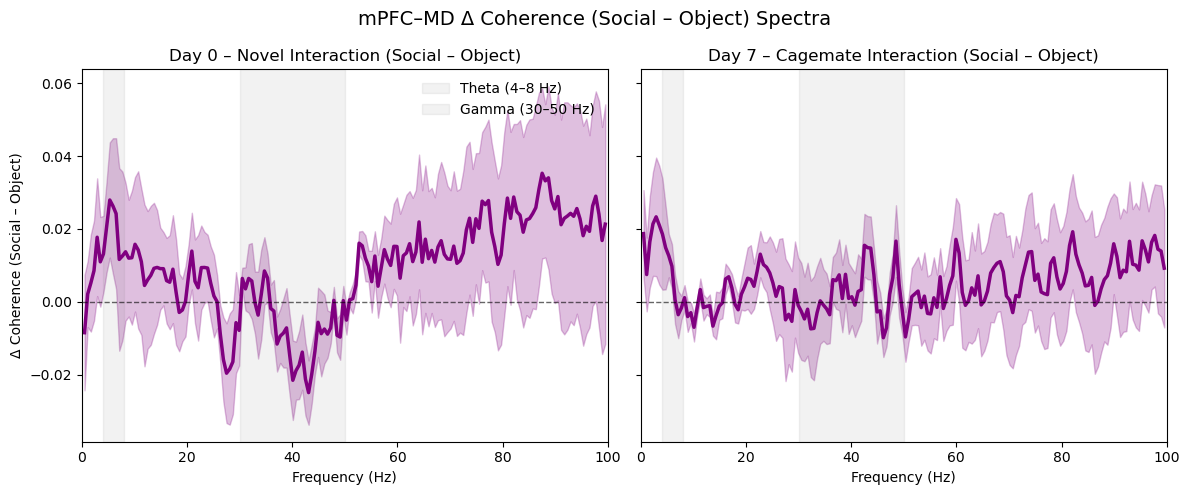

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# --- Compute Δ coherence (social - object) per subject ---
diff_d0 = np.array(social_d0) - np.array(object_d0)
diff_d7 = np.array(social_d7) - np.array(object_d7)

# --- Compute group mean and SEM ---
mean_diff_d0 = np.nanmean(diff_d0, axis=0)
sem_diff_d0  = np.nanstd(diff_d0, axis=0) / np.sqrt(diff_d0.shape[0])
mean_diff_d7 = np.nanmean(diff_d7, axis=0)
sem_diff_d7  = np.nanstd(diff_d7, axis=0) / np.sqrt(diff_d7.shape[0])

# --- Frequency mask (focus on 0–100 Hz) ---
valid = freqs <= 100

# --- Define frequency bands for shading ---
theta_band = (4, 8)
gamma_band = (30, 50)

# --- Plot Δ coherence ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ---------- Day 0 (Novel) ----------
axs[0].plot(freqs[valid], mean_diff_d0[valid], color="purple", lw=2.5)
axs[0].fill_between(freqs[valid],
                    mean_diff_d0[valid] - sem_diff_d0[valid],
                    mean_diff_d0[valid] + sem_diff_d0[valid],
                    color="purple", alpha=0.25)
axs[0].axhline(0, color="k", lw=1, linestyle="--", alpha=0.6)
axs[0].axvspan(*theta_band, color="gray", alpha=0.1, label="Theta (4–8 Hz)")
axs[0].axvspan(*gamma_band, color="gray", alpha=0.1, label="Gamma (30–50 Hz)")
axs[0].set_title("Day 0 – Novel Interaction (Social – Object)")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_xlim(0, 100)
axs[0].set_ylabel("Δ Coherence (Social – Object)")

# ---------- Day 7 (Cagemate) ----------
axs[1].plot(freqs[valid], mean_diff_d7[valid], color="purple", lw=2.5)
axs[1].fill_between(freqs[valid],
                    mean_diff_d7[valid] - sem_diff_d7[valid],
                    mean_diff_d7[valid] + sem_diff_d7[valid],
                    color="purple", alpha=0.25)
axs[1].axhline(0, color="k", lw=1, linestyle="--", alpha=0.6)
axs[1].axvspan(*theta_band, color="gray", alpha=0.1)
axs[1].axvspan(*gamma_band, color="gray", alpha=0.1)
axs[1].set_title("Day 7 – Cagemate Interaction (Social – Object)")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_xlim(0, 100)

# --- Formatting ---
fig.suptitle("mPFC–MD Δ Coherence (Social – Object) Spectra", fontsize=14)
axs[0].legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


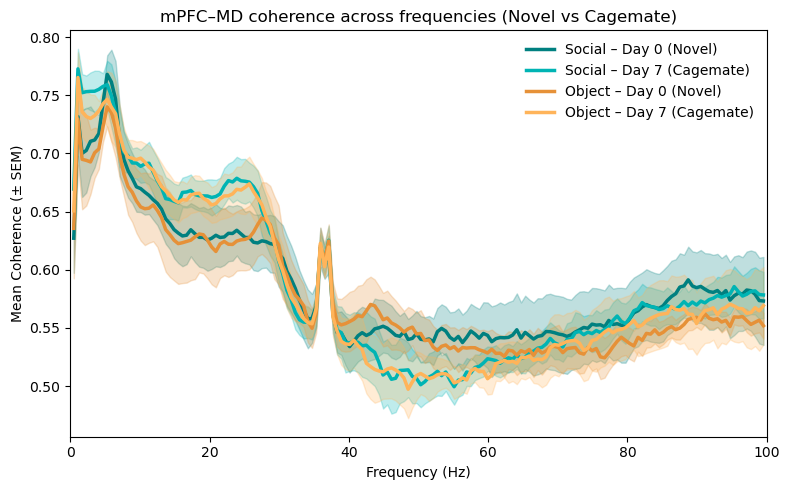

In [46]:
# --- Focus on 0–100 Hz range ---
valid = freqs <= 100

fig, ax = plt.subplots(figsize=(8, 5))

# === SOCIAL ===
ax.plot(freqs[valid], mean_social_d0[valid],
        color=(0/255, 128/255, 128/255), lw=2.5, label="Social – Day 0 (Novel)")
ax.fill_between(freqs[valid],
                mean_social_d0[valid] - sem_social_d0[valid],
                mean_social_d0[valid] + sem_social_d0[valid],
                color=(0/255, 128/255, 128/255), alpha=0.25)

ax.plot(freqs[valid], mean_social_d7[valid],
        color=(0/255, 180/255, 180/255), lw=2.5, label="Social – Day 7 (Cagemate)")
ax.fill_between(freqs[valid],
                mean_social_d7[valid] - sem_social_d7[valid],
                mean_social_d7[valid] + sem_social_d7[valid],
                color=(0/255, 180/255, 180/255), alpha=0.25)

# === OBJECT ===
ax.plot(freqs[valid], mean_object_d0[valid],
        color=(230/255, 145/255, 56/255), lw=2.5, label="Object – Day 0 (Novel)")
ax.fill_between(freqs[valid],
                mean_object_d0[valid] - sem_object_d0[valid],
                mean_object_d0[valid] + sem_object_d0[valid],
                color=(230/255, 145/255, 56/255), alpha=0.25)

ax.plot(freqs[valid], mean_object_d7[valid],
        color=(255/255, 180/255, 90/255), lw=2.5, label="Object – Day 7 (Cagemate)")
ax.fill_between(freqs[valid],
                mean_object_d7[valid] - sem_object_d7[valid],
                mean_object_d7[valid] + sem_object_d7[valid],
                color=(255/255, 180/255, 90/255), alpha=0.25)

# --- Formatting ---
ax.set_title("mPFC–MD coherence across frequencies (Novel vs Cagemate)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Mean Coherence (± SEM)")
ax.set_xlim(0, 100)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

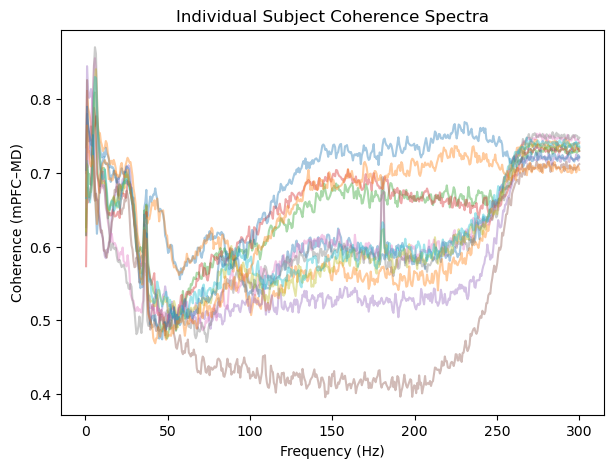

In [38]:
valid = freqs <= 100
plt.figure(figsize=(7,5))
for subj, social, object_ in zip(condition_order.keys(), social_all, object_all):
    plt.plot(freqs, social, alpha=0.4, label=f"{subj} social")
    plt.plot(freqs, object_, alpha=0.4, label=f"{subj} object")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence (mPFC–MD)")
plt.title("Individual Subject Coherence Spectra")
plt.show()


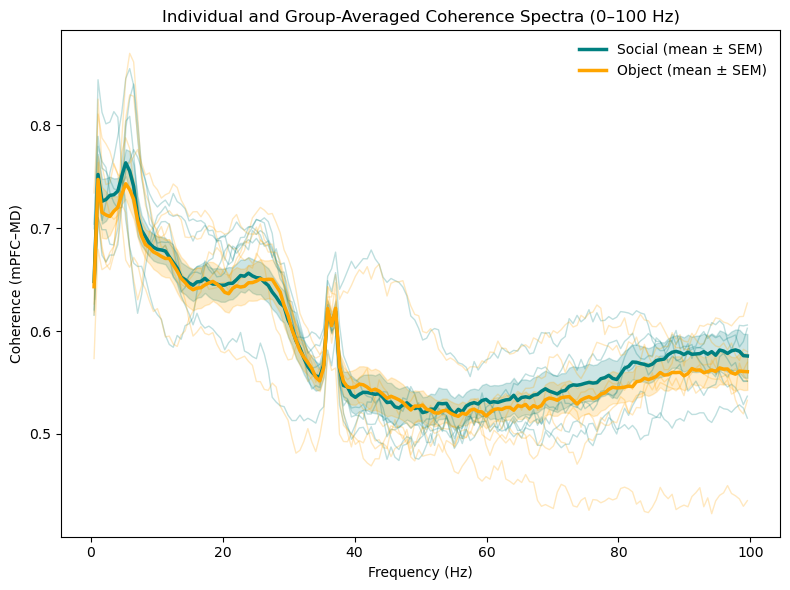

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute SEM ---
sem_social = np.nanstd(social_all, axis=0) / np.sqrt(len(social_all))
sem_object = np.nanstd(object_all, axis=0) / np.sqrt(len(object_all))

# --- Limit frequency range (e.g., 0–100 Hz) ---
valid = freqs <= 100

# --- Plot setup ---
plt.figure(figsize=(8, 6))

# Individual traces
for subj, social, object_ in zip(condition_order.keys(), social_all, object_all):
    plt.plot(freqs[valid], social[valid], color="teal", alpha=0.25, lw=1)
    plt.plot(freqs[valid], object_[valid], color="orange", alpha=0.25, lw=1)

# Group mean ± SEM
plt.plot(freqs[valid], mean_social[valid], color="teal", lw=2.5, label="Social (mean ± SEM)")
plt.fill_between(freqs[valid],
                 mean_social[valid] - sem_social[valid],
                 mean_social[valid] + sem_social[valid],
                 color="teal", alpha=0.2)

plt.plot(freqs[valid], mean_object[valid], color="orange", lw=2.5, label="Object (mean ± SEM)")
plt.fill_between(freqs[valid],
                 mean_object[valid] - sem_object[valid],
                 mean_object[valid] + sem_object[valid],
                 color="orange", alpha=0.2)

# --- Formatting ---
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence (mPFC–MD)")
plt.title("Individual and Group-Averaged Coherence Spectra (0–100 Hz)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


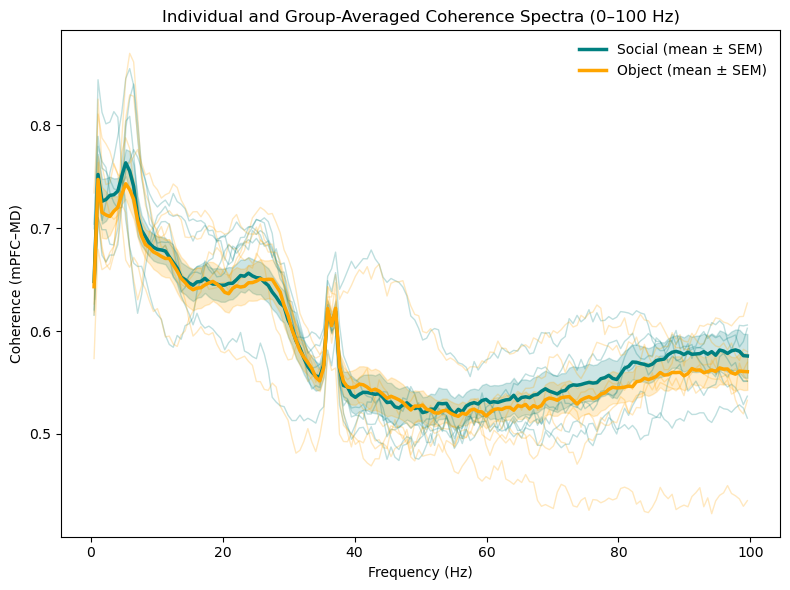

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute SEM ---
sem_social = np.nanstd(social_all, axis=0) / np.sqrt(len(social_all))
sem_object = np.nanstd(object_all, axis=0) / np.sqrt(len(object_all))

# --- Limit frequency range (e.g., 0–100 Hz) ---
valid = freqs <= 100

# --- Plot setup ---
plt.figure(figsize=(8, 6))

# Individual traces
for subj, social, object_ in zip(condition_order.keys(), social_all, object_all):
    plt.plot(freqs[valid], social[valid], color="teal", alpha=0.25, lw=1)
    plt.plot(freqs[valid], object_[valid], color="orange", alpha=0.25, lw=1)

# Group mean ± SEM
plt.plot(freqs[valid], mean_social[valid], color="teal", lw=2.5, label="Social (mean ± SEM)")
plt.fill_between(freqs[valid],
                 mean_social[valid] - sem_social[valid],
                 mean_social[valid] + sem_social[valid],
                 color="teal", alpha=0.2)

plt.plot(freqs[valid], mean_object[valid], color="orange", lw=2.5, label="Object (mean ± SEM)")
plt.fill_between(freqs[valid],
                 mean_object[valid] - sem_object[valid],
                 mean_object[valid] + sem_object[valid],
                 color="orange", alpha=0.2)

# --- Formatting ---
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence (mPFC–MD)")
plt.title("Individual and Group-Averaged Coherence Spectra (0–100 Hz)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Coherence now made | Loading behaviors for analysis

In [14]:
rec = lfp_collection.recordings[0]
print(rec.name)
print(rec.event_dict.keys())  # List of behavior types (e.g., 'sniffing', 'fighting', etc.)

41_rehouse_d7_merged.rec
dict_keys(['anogenital sniffing', 'chasing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])


### Creating time vector to allow us to put an event behavior mask over coherence

### We have one value per time window .shape[0], but we don't have a timestamp attached to thosse windows, we create it here with the timestep taking the time at the center of each window

In [16]:
def create_time_vector(rec):
    T = rec.coherence.shape[0]
    step = rec.timestep  # this is usually 0.1 or 0.5s
    tvec = np.arange(T) * step
    return tvec

In [17]:
tvec = create_time_vector(rec)
print("tvec shape:", tvec.shape)
print("Start:", tvec[0], "End:", tvec[-1])


tvec shape: (3600,)
Start: 0.0 End: 1799.5


In [18]:
def make_event_mask(tvec, event_ranges):
    """
    Create a boolean mask over `tvec` for all event time ranges.
    """
    mask = np.zeros_like(tvec, dtype=bool)
    for start, stop in event_ranges:
        mask |= (tvec >= start) & (tvec <= stop)
    return mask


In [19]:
for rec in lfp_collection.recordings:
    rec.tvec = create_time_vector(rec)
    print(rec.tvec)

[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7985e+03 1.7990e+03 1.7995e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.8000e+03 1.8005e+03 1.8010e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.8000e+03 1.8005e+03 1.8010e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7980e+03 1.7985e+03 1.7990e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.8000e+03 1.8005e+03 1.8010e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.8000e+03 1.8005e+03 1.8010e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]
[0.0000e+00 5.0000e-01 1.0000e+00 ... 1.7990e+03 1.7995e+03 1.8000e+03]


In [20]:
print(f"{rec.name}:")
print(f"  - first_timestamp: {rec.first_timestamp}")
print(f"  - timestep: {rec.timestep}")
print(f"  - coherence.shape[0] = {rec.coherence.shape[0]}")
print(f"  - tvec[0:5] = {tvec[:5]}")
print(f"  - tvec[-5:] = {tvec[-5:]}")


32_rehouse_d0_merged.rec:
  - first_timestamp: 2490408
  - timestep: 0.5
  - coherence.shape[0] = 3601
  - tvec[0:5] = [0.  0.5 1.  1.5 2. ]
  - tvec[-5:] = [1797.5 1798.  1798.5 1799.  1799.5]


In [21]:
print(rec.name)

32_rehouse_d0_merged.rec


In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_event_coherence(
    lfp_collection, event='sniffing object', region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    curves = []

    for rec in lfp_collection.recordings:
        # Skip recordings without the event
        if event not in rec.event_dict:
            continue

        region_dict = rec.brain_region_dict
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        # mask
        mask = make_event_mask(rec.tvec, rec.event_dict[event])
        if not np.any(mask):
            continue

        # Filter coherence during event
        coh_event = rec.coherence[mask]  # (T_event, F, R, R)
        avg_coh = np.nanmean(coh_event, axis=0)  # (F, R, R)

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]
        F, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            continue

        coh_curve = avg_coh[:, from_idx, to_idx]
        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
        day = 'd0' if 'd0' in rec.name else 'd7'  # optionally improve this too

        # Detect day and familiarity
        if 'd0' in rec.name.lower():
            fam = 'low fam'
            fam_short = 'low fam'
        elif 'd7' in rec.name.lower():
            fam = 'high fam'
            fam_short = 'high fam'
        else:
            fam = 'unknown fam'
            fam_short = 'unknown'

        label = f"subj {subj} - {fam_short}"
        curves.append((label, freqs_plot, coh_plot, subj, fam, rec.name))


    if not curves:
        print(f"⚠️ No valid data to plot for event '{event}' and region {region_from} - {region_to}")
        return

    subjects = sorted(set(subj for _, _, _, subj, _, _ in curves))
    cmap = plt.get_cmap('tab10', len(subjects))
    # or
    # cmap = matplotlib.colormaps['tab10']

    subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

    plt.figure(figsize=(10, 6))
    for label, freqs, coh, subj, fam, rec_name in curves:
        if fam!='high fam' and fam!='low fam':
            print("error in fam")
            break
        linestyle = '--' if fam == 'high fam' else '-'
        color = subject_colors[subj]
        plt.plot(freqs, coh, label=label, linewidth=1.5, linestyle=linestyle, color=color)

        print(f"➡️  {rec_name}: Subject={subj}, Day={fam}, Freq Shape={freqs.shape}, Coherence Mean={np.nanmean(coh):.3f}")




    plt.title(title if title else f"{region_from} - {region_to} Coherence during '{event}'", fontsize=20)
    plt.xlabel("Frequency (Hz)", fontsize=16)
    plt.ylabel("Coherence", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(False)
    plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=14)

    # Save or show
    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_{event.replace(' ', '_')}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


In [23]:
plot_event_coherence(
    lfp_collection,
    event='facial sniffing',
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during 'facial sniffing'",
    save_path="/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/"
)

plot_event_coherence(
    lfp_collection,
    event='facial sniffing',
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during 'facial sniffing'",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)


⚠️ No valid data to plot for event 'facial sniffing' and region mPFC - NAc
⚠️ No valid data to plot for event 'facial sniffing' and region mPFC - MD


In [24]:
plot_event_coherence(
    lfp_collection,
    event='anogenital sniffing',
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during 'anogenital sniffing'",
    save_path="/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/"
)

plot_event_coherence(
    lfp_collection,
    event='anogenital sniffing',
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during 'anogenital sniffing'",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)


⚠️ No valid data to plot for event 'anogenital sniffing' and region mPFC - NAc
⚠️ No valid data to plot for event 'anogenital sniffing' and region mPFC - MD


In [25]:
plot_event_coherence(
    lfp_collection,
    event='chasing',
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during 'fighting'",
    # save_path="/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/"
)

plot_event_coherence(
    lfp_collection,
    event='chasing',
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during 'fighting'",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)


⚠️ No valid data to plot for event 'chasing' and region mPFC - NAc
⚠️ No valid data to plot for event 'chasing' and region mPFC - MD


In [26]:
plot_event_coherence(
    lfp_collection,
    event='fighting',
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during 'fighting'",
    # save_path="/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/"
)

plot_event_coherence(
    lfp_collection,
    event='fighting',
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during 'fighting'",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)


⚠️ No valid data to plot for event 'fighting' and region mPFC - NAc
⚠️ No valid data to plot for event 'fighting' and region mPFC - MD


In [27]:
plot_event_coherence(
    lfp_collection,
    event='sniffing object',
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during 'sniffing object'",
    save_path="/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/"
)

plot_event_coherence(
    lfp_collection,
    event='sniffing object',
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during 'sniffing object'",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)


⚠️ No valid data to plot for event 'sniffing object' and region mPFC - NAc
⚠️ No valid data to plot for event 'sniffing object' and region mPFC - MD


In [28]:
def plot_event_coherence(
    lfp_collection, events='sniffing object', region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    if isinstance(events, str):
        events = [events]  # convert to list if single string

    curves = []

    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        # Combine masks for all requested events
        tvec = create_time_vector(rec)
        combined_mask = np.zeros_like(tvec, dtype=bool)
        valid = False

        for event in events:
            if event in rec.event_dict:
                mask = make_event_mask(tvec, rec.event_dict[event])
                combined_mask |= mask  # logical OR
                valid = True

        if not valid or not np.any(combined_mask):
            continue

        coh_event = rec.coherence[combined_mask]  # (T_event, F, R, R)
        avg_coh = np.nanmean(coh_event, axis=0)  # (F, R, R)

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]
        F, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            continue

        coh_curve = avg_coh[:, from_idx, to_idx]
        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]

        if 'd0' in rec.name.lower():
            fam = 'low fam'
        elif 'd7' in rec.name.lower():
            fam = 'high fam'
        else:
            fam = 'unknown fam'

        label = f"subj {subj} - {fam}"
        curves.append((label, freqs_plot, coh_plot, subj, fam, rec.name))

    if not curves:
        print(f"⚠️ No valid data to plot for events {events} and region {region_from} - {region_to}")
        return

    # Define hardcoded RGB colors (0–1 scale)
    low_fam_color = (1/255, 138/255, 126/255)   # d0
    high_fam_color = (100/255, 5/255, 49/255)   # d7

    plt.figure(figsize=(5.5, 5.5))
    for label, freqs, coh, subj, fam, rec_name in curves:
        if fam == 'low fam':
            color = low_fam_color
            linestyle = '-'
        elif fam == 'high fam':
            color = high_fam_color
            linestyle = '--'
        else:
            color = 'gray'
            linestyle = ':'

        plt.plot(freqs, coh, label=label, linewidth=2.5, linestyle=linestyle, color=color)
        print(f"➡️  {rec_name}: Subject={subj}, Day={fam}, Freq Shape={freqs.shape}, Coherence Mean={np.nanmean(coh):.3f}")


    event_str = ', '.join(events)
    plt.title(title if title else f"{region_from} - {region_to} Coherence during {event_str}", fontsize=18)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("Coherence", fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(False)
    plt.ylim(0.35, 1)
    plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=14)

    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_{'_'.join(e.replace(' ', '_') for e in events)}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


In [29]:
plot_event_coherence(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during Social Investigation",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)
plot_event_coherence(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during Social Investigation",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)


⚠️ No valid data to plot for events ['facial sniffing', 'anogenital sniffing'] and region mPFC - NAc
⚠️ No valid data to plot for events ['facial sniffing', 'anogenital sniffing'] and region mPFC - MD


In [30]:
def plot_event_coherence_avg_fam(
    lfp_collection, events='sniffing object', region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    if isinstance(events, str):
        events = [events]

    # Gather all coherence curves for each fam across subjects
    subj_data = defaultdict(list)
    freqs_plot = None  # For use in plotting

    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        tvec = create_time_vector(rec)
        combined_mask = np.zeros_like(tvec, dtype=bool)
        valid = False

        for event in events:
            if event in rec.event_dict:
                mask = make_event_mask(tvec, rec.event_dict[event])
                combined_mask |= mask
                valid = True

        if not valid or not np.any(combined_mask):
            continue

        coh_event = rec.coherence[combined_mask]  # (T_event, F, R, R)
        avg_coh = np.nanmean(coh_event, axis=0)   # (F, R, R)

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]
        F, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            continue

        coh_curve = avg_coh[:, from_idx, to_idx]
        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        # Figure out familiarity condition
        if 'd0' in rec.name.lower():
            fam = 'low fam'
        elif 'd7' in rec.name.lower():
            fam = 'high fam'
        else:
            fam = 'unknown fam'

        subj_data[fam].append(coh_plot)

    if not subj_data:
        print(f"⚠️ No valid data to plot for events {events} and region {region_from} - {region_to}")
        return

    # --- Define colors ---
    low_fam_color = (1/255, 138/255, 126/255)
    high_fam_color = (100/255, 5/255, 49/255)

    plt.figure(figsize=(5.5, 5.5))

    # --- Plot two lines: avg low fam, avg high fam ---
    for fam, curves in subj_data.items():
        coh_array = np.stack(curves, axis=0)  # (N_total_rec, F)
        mean_coh = np.nanmean(coh_array, axis=0)

        if fam == 'low fam':
            color = low_fam_color
            linestyle = '-'
        elif fam == 'high fam':
            color = high_fam_color
            linestyle = '-'
        else:
            color = 'gray'
            linestyle = ':'

        label = f"{fam}"
        plt.plot(freqs_plot, mean_coh, label=label, linewidth=2.5, linestyle=linestyle, color=color)
        print(f"📊 Averaged {fam}: {coh_array.shape[0]} recordings, Mean coherence = {np.nanmean(mean_coh):.3f}")

    # --- Pretty up plot ---
    event_str = ', '.join(events)
    plt.title(title if title else f"{region_from} - {region_to} Coherence during {event_str}", fontsize=18)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("Coherence", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(False)
    plt.ylim(0.35, 1)
    plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=14)

    # --- Save or show ---
    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_avgfam_{'_'.join(e.replace(' ', '_') for e in events)}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


In [31]:
plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during Social Investigation",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)
plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during Social Investigation",
    save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)


⚠️ No valid data to plot for events ['facial sniffing', 'anogenital sniffing'] and region mPFC - NAc
⚠️ No valid data to plot for events ['facial sniffing', 'anogenital sniffing'] and region mPFC - MD


In [32]:
!jupyter nbconvert --to script coherence_41_44.ipynb

[NbConvertApp] Converting notebook coherence_41_44.ipynb to script
[NbConvertApp] Writing 32394 bytes to coherence_41_44.py


### Directionality plots for ***mpfc*** -> ***nac*** and ***mpfc*** -> ***md***

In [33]:
def coh_plot(rec, freqs, mpfc_to_nac, mpfc_to_md, save_dir=None):
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, mpfc_to_nac, label='mPFC → NAc', color='blue')
    plt.plot(freqs, mpfc_to_md, label='mPFC → MD', color='green')
    plt.title(f"Average Coherence Directionality — {rec.name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_dir is not None:
        # Safe file name
        fname = f"coh_{rec.name.replace('.rec','')}.png"
        plt.savefig(os.path.join(save_dir, fname))
        plt.close()
    else:
        plt.show()

In [34]:
# Pick a recording to visualize
d0_44 = lfp_collection.recordings[0]

In [35]:
# Get region indices
region_dict = d0_44.brain_region_dict
mpfc_idx = region_dict['mPFC']
nac_idx = region_dict['NAc']
md_idx = region_dict['MD']

### Get Average, spectra for each direction, slice freqs 

In [36]:
# Average over time (T axis)
avg_coh = np.nanmean(d0_44.coherence, axis=0)  # shape: (F, R, R)

# Get coherence spectra for each direction
mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]
mpfc_to_md = avg_coh[:, mpfc_idx, md_idx]

# Slice to 0–100 Hz only
freqs = d0_44.frequencies  # full frequency vector, e.g., 0–500 Hz
freq_mask = freqs <= 100
freqs = freqs[freq_mask]
mpfc_to_nac = mpfc_to_nac[freq_mask]
mpfc_to_md = mpfc_to_md[freq_mask]

/scratch/local/16057860/ipykernel_1337517/2152753303.py:2: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(d0_44.coherence, axis=0)  # shape: (F, R, R)


In [37]:
print("avg_coh shape:", avg_coh.shape)
print("brain regions in recording:", rec.brain_region_dict)
print("mpfc_idx:", mpfc_idx, "nac_idx:", nac_idx, "bla_idx:", rec.brain_region_dict.get("BLA", "not found"))


avg_coh shape: (500, 5, 5)
brain regions in recording: bidict({'BLA': 3, 'MD': 2, 'NAc': 1, 'mPFC': 0, 'vHPC': 4})
mpfc_idx: 0 nac_idx: 1 bla_idx: 3


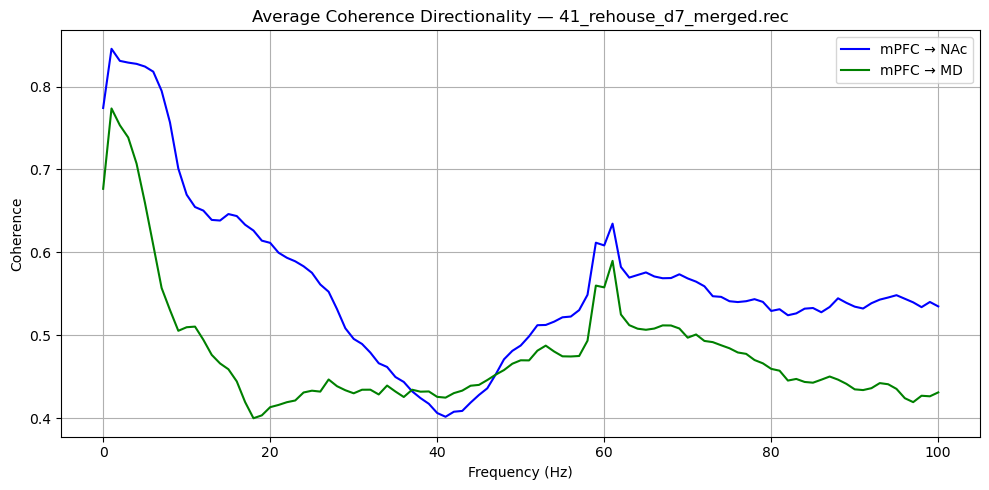

In [38]:
# Plot
coh_plot(d0_44, freqs, mpfc_to_nac, mpfc_to_md)

### Plots of 4.1 and 4.4 coherence directionality mpfc -> nac and mpfc -> MD

Processing 41_rehouse_d7_merged.rec


/scratch/local/16057860/ipykernel_1337517/2231502305.py:14: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


PermissionError: [Errno 13] Permission denied: '/blue/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/coh_41_rehouse_d7_merged.png'

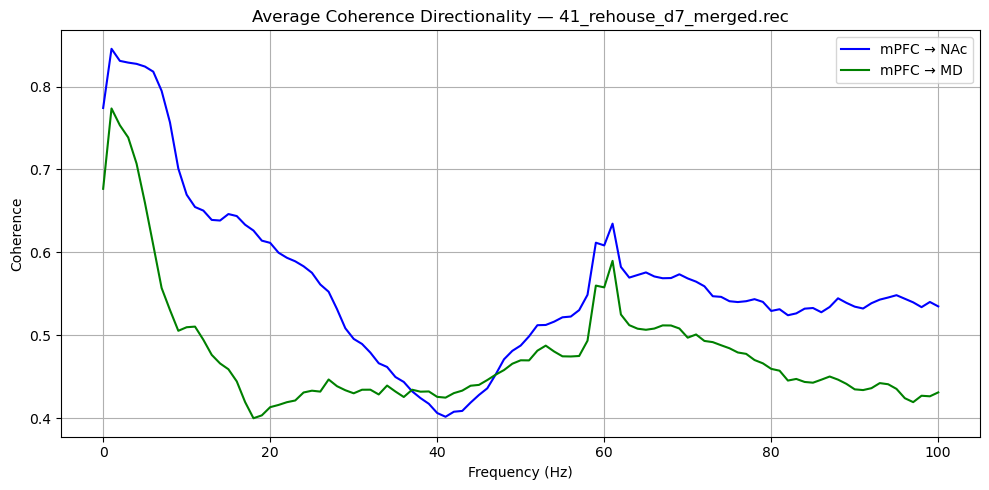

In [39]:
for rec in lfp_collection.recordings:
    print(f"Processing {rec.name}")
    region_dict = rec.brain_region_dict

    # Skip if any region is missing (shouldn't happen with your recordings)
    if not all(region in region_dict for region in ['mPFC', 'NAc', 'MD']):
        print(f"Skipping {rec.name}: required regions not found.")
        continue

    mpfc_idx = region_dict['mPFC']
    nac_idx = region_dict['NAc']
    md_idx = region_dict['MD']

    avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
    mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]
    mpfc_to_md = avg_coh[:, mpfc_idx, md_idx]

    # Frequency restriction
    freqs = rec.frequencies
    freq_mask = freqs <= 100
    freqs_plot = freqs[freq_mask]
    mpfc_to_nac_plot = mpfc_to_nac[freq_mask]
    mpfc_to_md_plot = mpfc_to_md[freq_mask]

    # Plot (and/or save)
    coh_plot(
        rec, 
        freqs_plot, 
        mpfc_to_nac_plot, 
        mpfc_to_md_plot,
        save_dir='/home/t.heeps/blue_npadillacoreano/rehouse_code/coherence_plots/plots',
    )

/scratch/local/16057860/ipykernel_1337517/3628726135.py:15: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


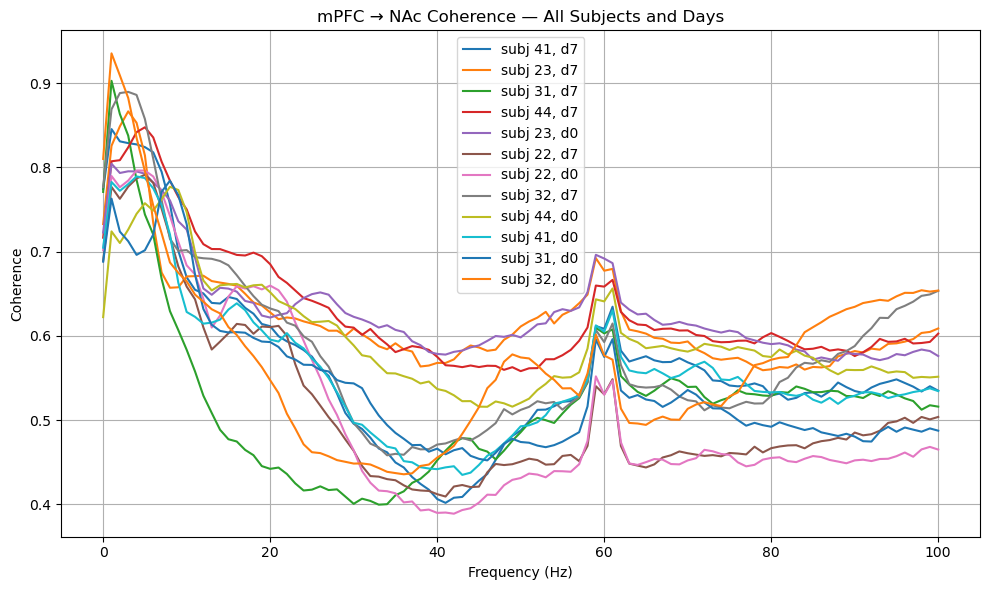

In [40]:
# Collect all mPFC-NAc curves for each (subject, day)
curves = []  # Each item: (label, freqs, coherence)

for rec in lfp_collection.recordings:
    region_dict = rec.brain_region_dict
    if not all(region in region_dict for region in ['mPFC', 'NAc']):
        continue

    # Subject and day — adjust as needed based on your actual attributes
    subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
    day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

    mpfc_idx = region_dict['mPFC']
    nac_idx = region_dict['NAc']
    avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
    mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]

    freqs = rec.frequencies
    freq_mask = freqs <= 100
    freqs_plot = freqs[freq_mask]
    mpfc_to_nac_plot = mpfc_to_nac[freq_mask]

    label = f"subj {subj}, {day}"
    curves.append((label, freqs_plot, mpfc_to_nac_plot))

# Plot all on one figure
plt.figure(figsize=(10, 6))
for label, freqs, coh in curves:
    plt.plot(freqs, coh, label=label)
plt.title("mPFC → NAc Coherence — All Subjects and Days")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Optionally save:
# plt.savefig('mpfc_nac_all_subjects_days.png')
# plt.close()


In [41]:
for rec in lfp_collection.recordings:
    print(f"Recording: {rec.name} (Subject: {rec.subject}) — Regions: {list(rec.brain_region_dict.keys())}")


Recording: 41_rehouse_d7_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 23_rehouse_d7_merged.rec (Subject: 23) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 31_rehouse_d7_merged.rec (Subject: 31) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d7_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 23_rehouse_d0_merged.rec (Subject: 23) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 22_rehouse_d7_merged.rec (Subject: 22) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 22_rehouse_d0_merged.rec (Subject: 22) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 32_rehouse_d7_merged.rec (Subject: 32) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d0_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d0_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 31_rehous

In [42]:
print("🔍 Verifying brain region integrity for each recording...\n")
for rec in lfp_collection.recordings:
    region_dict = rec.brain_region_dict
    region_names = list(region_dict.keys())

    coh_shape = rec.coherence.shape  # (T, F, R, R)
    T, F, R, _ = coh_shape

    # Reverse mapping: index to region (e.g., 0 → 'mPFC')
    reverse_map = {v: k for k, v in region_dict.items()}
    region_list_from_indices = [reverse_map.get(i, 'MISSING') for i in range(R)]

    print(f"📁 {rec.name} (Subject: {rec.subject})")
    print(f"  - Regions in dict:      {region_names}")
    print(f"  - Coherence shape:      {coh_shape}")
    print(f"  - Region count (R):     {R}")
    print(f"  - Regions by index map: {region_list_from_indices}")
    print(f"  - Missing regions:      {[r for r in ['mPFC','NAc','MD','vHPC','BLA'] if r not in region_names]}")
    print()


🔍 Verifying brain region integrity for each recording...

📁 41_rehouse_d7_merged.rec (Subject: 41)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3600, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 23_rehouse_d7_merged.rec (Subject: 23)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3603, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 31_rehouse_d7_merged.rec (Subject: 31)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3603, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 44_rehouse_d7_merged.rec (Subject: 44)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3599

In [43]:
for recs in lfp_collection.recordings:
    print(f"{recs.name}, {recs.event_dict.keys()}")

41_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'chasing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])
23_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])
31_rehouse_d7_merged.rec, dict_keys(['fighting', 'mice back in', 'mice taken out', 'sniffing object'])
44_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])
23_rehouse_d0_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object'])
22_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object'])
22_rehouse_d0_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object'])
32_rehouse_d7_merged.rec, dict_keys(['anogenital sni

### Plotting d0 and d7 rec together comparing coherence difference

/scratch/local/16057860/ipykernel_1337517/3426632245.py:18: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


PermissionError: [Errno 13] Permission denied: '/blue/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/mPFC_to_NAc.png'

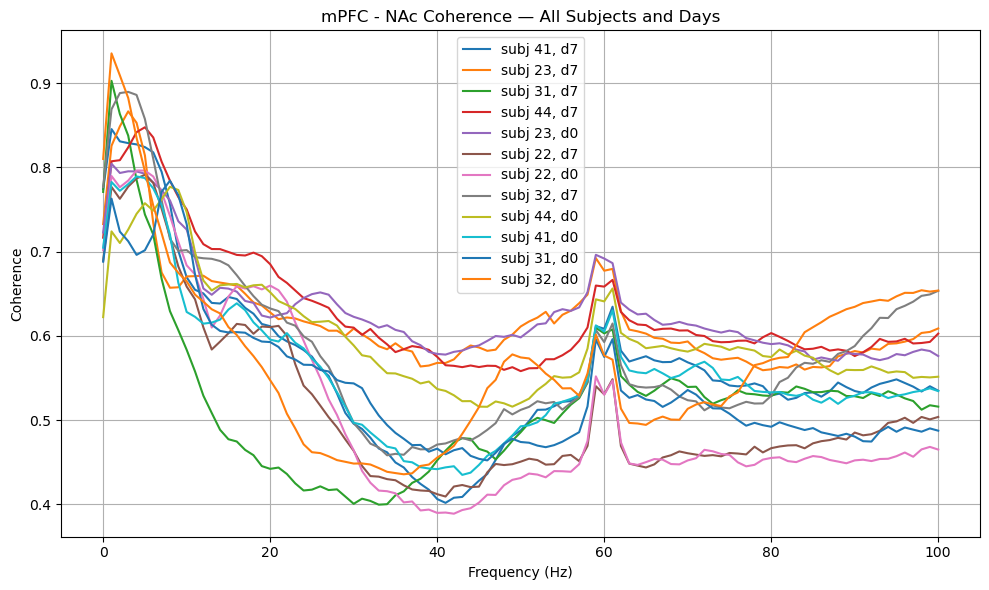

In [44]:
from pathlib import Path

def plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    curves = []
    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict

        # Skip if either region missing in dictionary
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]

        avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
        _, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            print(f"⚠️ Skipping {rec.name}: index ({from_idx}, {to_idx}) out of bounds for R={R}")
            continue

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
        day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

        coh_curve = avg_coh[:, from_idx, to_idx]

        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        label = f"subj {subj}, {day}"
        curves.append((label, freqs_plot, coh_plot))

    if not curves:
        print(f"⚠️ No valid data to plot for {region_from} - {region_to}")
        return

    # Plot
    plt.figure(figsize=(10, 6))
    for label, freqs, coh in curves:
        plt.plot(freqs, coh, label=label)
    plt.title(title if title else f"{region_from} - {region_to} Coherence — All Subjects and Days")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save to file
    if save_path:
        # Ensure directory exists
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


# Example usage
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='MD', save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='vHPC', title="mPFC → vHPC Coherence"
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='BLA', title="mPFC → BLA Coherence"
)

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

def plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    curves = []
    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict

        # Skip if either region missing in dictionary
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]

        avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
        _, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            print(f"⚠️ Skipping {rec.name}: index ({from_idx}, {to_idx}) out of bounds for R={R}")
            continue

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
        day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

        coh_curve = avg_coh[:, from_idx, to_idx]

        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        label = f"subj {subj}, {day}"
        curves.append((label, freqs_plot, coh_plot))

    if not curves:
        print(f"⚠️ No valid data to plot for {region_from} - {region_to}")
        return


    # Extract unique subject IDs
    subjects = sorted(set(label.split(',')[0].split()[-1] for label, _, _ in curves))
    
    # Generate color map
    cmap = cm.get_cmap('tab10', len(subjects))  # or 'Set1', 'tab20', etc.
    subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

    plt.figure(figsize=(10, 6))

    for label, freqs, coh in curves:
        subj = label.split(',')[0].split()[-1]
        day = label.split(',')[1].strip()

        linestyle = '--' if day == 'd7' else '-'
        color = subject_colors[subj]

        plt.plot(freqs, coh, label=label, linewidth=1.1, linestyle=linestyle, color=color)

    plt.title(title if title else f"{region_from} - {region_to} Coherence — All Subjects and Days")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    # Save or show the plot
    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_color_same.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


# Example usage
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='MD', save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='vHPC', title="mPFC → vHPC Coherence"
)

### Filtering coherence data to only include coherence during the tone

In [45]:
!jupyter nbconvert --to script coherence_41_44.ipynb

[NbConvertApp] Converting notebook coherence_41_44.ipynb to script
[NbConvertApp] Writing 32394 bytes to coherence_41_44.py


In [46]:
print(dir(d0_44))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__interpolate_coherence_granger__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get_selected_traces', '_read_trodes', 'brain_region_dict', 'calculate_all', 'calculate_coherence', 'calculate_granger_causality', 'calculate_power', 'channel_dict', 'coherence', 'connectivity', 'elec_noise_freq', 'event_dict', 'exclude_regions', 'export_trodes_timestamps', 'find_start_recording_time', 'first_timestamp', 'frequencies', 'get_all_channels', 'halfbandwidth', 'interpolate_coherence', 'interpolate_granger', 'interpolate_power', 'load_rec_from_h5', 'max_freq', 'merged_rec_path', 'min_freq', 'name', 'plot_all_channels', 'plot_to_find_threshold', 'preprocess', 'rec_length', 'rec_path', 'resample_rate'

In [47]:
d0_44.event_dict

{'anogenital sniffing': array([[ 605070.55,  605832.75],
        [ 630847.7 ,  631679.25],
        [ 697300.15,  701734.95],
        [ 763336.85,  763683.3 ],
        [ 981611.3 ,  983828.7 ],
        [1022633.05, 1023187.4 ],
        [1027275.7 , 1032611.3 ]]),
 'chasing': array([[604239.  , 604793.35],
        [606387.1 , 607149.35],
        [713653.4 , 714138.5 ],
        [718434.65, 718850.45]]),
 'facial sniffing': array([[ 607426.5 ,  608199.8 ],
        [ 608535.2 ,  609505.35],
        [ 624472.7 ,  624819.2 ],
        [ 643667.  ,  644498.55],
        [ 653645.25,  653922.45],
        [ 668820.55,  669652.05],
        [ 701804.25,  702150.7 ],
        [ 712267.55,  713168.35],
        [ 714623.55,  715524.35],
        [ 716979.5 ,  717672.45],
        [ 723077.35,  725993.1 ],
        [ 747676.5 ,  748230.85],
        [ 754467.3 ,  754952.35],
        [ 764930.6 ,  765415.65],
        [ 843024.35,  844063.75],
        [ 845033.85,  845865.4 ],
        [ 850646.65,  851201.  ],

In [48]:
!jupyter nbconvert --to script coherence_41_44.ipynb

[NbConvertApp] Converting notebook coherence_41_44.ipynb to script
[NbConvertApp] Writing 32394 bytes to coherence_41_44.py
